### Descripción de los datos

El conjunto de datos **Instacart Market Basket Analysis** contiene información anonimizada sobre los pedidos realizados por los clientes de Instacart, los productos incluidos en cada pedido y la clasificación de esos productos en pasillos y departamentos.

Los datos se distribuyen en las siguientes tablas:

- `orders.csv`
- `order_products__prior.csv`
- `order_products__train.csv`
- `products.csv`
- `aisles.csv`
- `departments.csv`
- `sample_submission.csv`

---

#### 1. Tabla `orders`

La tabla `orders` contiene la información general de cada pedido. Cada fila representa un pedido diferente.

| Columna | Descripción |
|---|---|
| `order_id` | Identificador único del pedido. Permite relacionar esta tabla con `order_products__prior` y `order_products__train`. |
| `user_id` | Identificador anónimo del cliente que realizó el pedido. Un mismo cliente puede aparecer en varias filas porque puede haber realizado varios pedidos. |
| `eval_set` | Conjunto al que pertenece el pedido. Puede tomar los valores `prior`, `train` o `test`. |
| `order_number` | Posición cronológica del pedido dentro del historial del cliente. El valor `1` representa el primer pedido del cliente, `2` el segundo y así sucesivamente. |
| `order_dow` | Día de la semana en el que se realizó el pedido, codificado mediante valores entre `0` y `6`. El conjunto de datos no especifica qué día concreto corresponde a cada número. |
| `order_hour_of_day` | Hora del día en la que se realizó el pedido, representada mediante valores entre `0` y `23`. |
| `days_since_prior_order` | Número de días transcurridos desde el pedido anterior del mismo cliente. Es nulo en el primer pedido porque no existe un pedido previo. Los valores están limitados a un máximo de 30 días, por lo que el valor `30` puede representar 30 días o más. |

##### Significado de `eval_set`

| Valor | Significado |
|---|---|
| `prior` | Pedidos históricos anteriores al último pedido disponible de cada cliente. |
| `train` | Último pedido de los clientes asignados al conjunto de entrenamiento. Los productos de estos pedidos aparecen en `order_products__train.csv`. |
| `test` | Último pedido de los clientes asignados al conjunto de prueba. Los productos incluidos en estos pedidos no se proporcionan, ya que debían ser predichos en la competición. |

Por tanto, cada cliente dispone de varios pedidos `prior` y de un último pedido clasificado como `train` o `test`.

---

#### 2. Tabla `order_products__prior`

La tabla `order_products__prior` contiene los productos incluidos en los pedidos históricos clasificados como `prior`.

Cada fila representa la aparición de un producto dentro de un pedido. Por tanto, un mismo `order_id` aparece tantas veces como productos contiene el pedido.

| Columna | Descripción |
|---|---|
| `order_id` | Identificador del pedido en el que aparece el producto. Se relaciona con la columna `order_id` de la tabla `orders`. |
| `product_id` | Identificador del producto incluido en el pedido. Se relaciona con la columna `product_id` de la tabla `products`. |
| `add_to_cart_order` | Posición en la que el producto fue añadido a la cesta. El valor `1` indica que fue el primer producto añadido, el valor `2` el segundo y así sucesivamente. |
| `reordered` | Indicador de recompra. Toma el valor `1` cuando el cliente ya había comprado ese producto en alguno de sus pedidos anteriores y `0` cuando era la primera vez que lo compraba. |

Esta tabla contiene la mayor parte del historial transaccional y puede utilizarse para analizar:

- Frecuencia de compra de los productos.
- Tamaño de las cestas.
- Comportamiento de recompra.
- Productos comprados conjuntamente.
- Preferencias históricas de cada cliente.

---

#### 3. Tabla `order_products__train`

La tabla `order_products__train` presenta la misma estructura que `order_products__prior`, pero contiene únicamente los productos de los pedidos clasificados como `train`.

Cada fila representa un producto incluido en el último pedido conocido de un cliente del conjunto de entrenamiento.

| Columna | Descripción |
|---|---|
| `order_id` | Identificador del pedido de entrenamiento. Se relaciona con un pedido cuyo `eval_set` es igual a `train` en la tabla `orders`. |
| `product_id` | Identificador del producto incluido en el pedido. Se relaciona con la tabla `products`. |
| `add_to_cart_order` | Posición en la que el producto fue añadido a la cesta dentro del pedido. |
| `reordered` | Indicador que señala si el cliente había comprado anteriormente ese producto. Toma el valor `1` si existía una compra previa y `0` si era la primera compra del producto. |

La diferencia principal entre las dos tablas transaccionales es:

- `order_products__prior`: contiene los productos de los pedidos históricos.
- `order_products__train`: contiene los productos del último pedido conocido de los clientes de entrenamiento.

No existe una tabla `order_products__test`, ya que los productos de los pedidos de prueba fueron ocultados para que los participantes de la competición los predijeran.

---

#### 4. Tabla `products`

La tabla `products` contiene el catálogo de productos disponibles.

Cada fila representa un producto diferente.

| Columna | Descripción |
|---|---|
| `product_id` | Identificador único del producto. Permite relacionar el producto con las tablas `order_products__prior` y `order_products__train`. |
| `product_name` | Nombre descriptivo del producto. |
| `aisle_id` | Identificador del pasillo al que pertenece el producto. Se relaciona con la tabla `aisles`. |
| `department_id` | Identificador del departamento al que pertenece el producto. Se relaciona con la tabla `departments`. |

Cada producto pertenece a un único pasillo y a un único departamento.

---

#### 5. Tabla `aisles`

La tabla `aisles` contiene los diferentes pasillos o categorías específicas en las que se organizan los productos.

Cada fila representa un pasillo diferente.

| Columna | Descripción |
|---|---|
| `aisle_id` | Identificador único del pasillo. Se relaciona con la columna `aisle_id` de la tabla `products`. |
| `aisle` | Nombre del pasillo o categoría específica de productos. |

Algunos ejemplos de pasillos pueden ser productos frescos, bebidas, yogures, aperitivos o productos de limpieza.

---

#### 6. Tabla `departments`

La tabla `departments` contiene las categorías generales o departamentos en los que se agrupan los productos.

Cada fila representa un departamento diferente.

| Columna | Descripción |
|---|---|
| `department_id` | Identificador único del departamento. Se relaciona con la columna `department_id` de la tabla `products`. |
| `department` | Nombre del departamento al que pertenecen los productos. |

Los departamentos representan una clasificación más general que los pasillos. Por ejemplo, varios pasillos diferentes pueden pertenecer al mismo departamento.

---


### Cargado de los datos y análisis inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

DATA_DIR = Path("../../data/instacart/")

In [2]:
orders = pd.read_csv(DATA_DIR / "orders.csv")
products = pd.read_csv(DATA_DIR / "products.csv")
aisles = pd.read_csv(DATA_DIR / "aisles.csv")
departments = pd.read_csv(DATA_DIR / "departments.csv")

order_products_prior = pd.read_csv(
    DATA_DIR / "order_products__prior.csv"
)

order_products_train = pd.read_csv(
    DATA_DIR / "order_products__train.csv"
)

In [3]:
tablas = {
    "orders": orders,
    "products": products,
    "aisles": aisles,
    "departments": departments,
    "order_products_prior": order_products_prior,
    "order_products_train": order_products_train
}

for nombre, df in tablas.items():
    print(f"{nombre}: {df.shape[0]:,} filas y {df.shape[1]} columnas")

orders: 3,421,083 filas y 7 columnas
products: 49,688 filas y 4 columnas
aisles: 134 filas y 2 columnas
departments: 21 filas y 2 columnas
order_products_prior: 32,434,489 filas y 4 columnas
order_products_train: 1,384,617 filas y 4 columnas


In [4]:
# Primeras filas de cada tabla

for nombre, df in tablas.items():
    print("\n" + "=" * 60)
    print(nombre.upper())
    print("=" * 60)
    display(df.head())


ORDERS


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.00
2,473747,1,prior,3,3,12,21.00
3,2254736,1,prior,4,4,7,29.00
4,431534,1,prior,5,4,15,28.00



PRODUCTS


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13



AISLES


...

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol



ORDER_PRODUCTS_PRIOR


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0



ORDER_PRODUCTS_TRAIN


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


In [5]:
for nombre, df in tablas.items():
    print("\n" + "=" * 60)
    print(nombre.upper())
    print("=" * 60)
    df.info()


ORDERS
<class 'pandas.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                str    
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), str(1)
memory usage: 182.7 MB

PRODUCTS
<class 'pandas.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     49688 non-null  int64
 1   product_name   49688 non-null  str  
 2   aisle_id       49688 non-null  int64
 3   department_id  49688 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB

AISLES
<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 co

In [6]:
for nombre, df in tablas.items():

    nulos = pd.DataFrame({
        "nulos": df.isnull().sum(),
        "porcentaje": df.isnull().mean() * 100
    })

    nulos = nulos[nulos["nulos"] > 0]

    print(f"\nValores nulos en {nombre}:")

    if nulos.empty:
        print("No existen valores nulos")
    else:
        display(nulos)


Valores nulos en orders:


,nulos,porcentaje
days_since_prior_order,206209,6.03



Valores nulos en products:
No existen valores nulos

Valores nulos en aisles:
No existen valores nulos

Valores nulos en departments:
No existen valores nulos

Valores nulos en order_products_prior:
No existen valores nulos

Valores nulos en order_products_train:
No existen valores nulos


In [7]:
orders.loc[
    orders["days_since_prior_order"].isna(),
    ["order_number", "days_since_prior_order"]
].head()

,order_number,days_since_prior_order
0,1,NaN
11,1,NaN
26,1,NaN
39,1,NaN
45,1,NaN


In [8]:
pd.crosstab(
    orders["order_number"] == 1,
    orders["days_since_prior_order"].isna(),
    rownames=["Es primer pedido"],
    colnames=["Days since prior es nulo"]
)

Days since prior es nulo,False,True
Es primer pedido,,
False,3214874,0
True,0,206209


In [9]:
for nombre, df in tablas.items():
    print(
        f"{nombre}: {df.duplicated().sum():,} filas completamente duplicadas"
    )

orders: 0 filas completamente duplicadas
products: 0 filas completamente duplicadas
aisles: 0 filas completamente duplicadas
departments: 0 filas completamente duplicadas
order_products_prior: 0 filas completamente duplicadas
order_products_train: 0 filas completamente duplicadas


#### Tratamiento de nulos

In [10]:
orders["first_order"] = (
    orders["order_number"] == 1
).astype(int)

orders["days_since_prior_order"] = (
    orders["days_since_prior_order"]
    .fillna(0)
)

In [11]:
for nombre, df in tablas.items():

    nulos = pd.DataFrame({
        "nulos": df.isnull().sum(),
        "porcentaje": df.isnull().mean() * 100
    })

    nulos = nulos[nulos["nulos"] > 0]

    print(f"\nValores nulos en {nombre}:")

    if nulos.empty:
        print("No existen valores nulos")
    else:
        display(nulos)


Valores nulos en orders:
No existen valores nulos

Valores nulos en products:
No existen valores nulos

Valores nulos en aisles:
No existen valores nulos

Valores nulos en departments:
No existen valores nulos

Valores nulos en order_products_prior:
No existen valores nulos

Valores nulos en order_products_train:
No existen valores nulos


#### Revisión de duplicados

In [12]:
# Comprobación de identificadores principales

print(
    "Order ID duplicados:",
    orders["order_id"].duplicated().sum()
)

print(
    "Product ID duplicados:",
    products["product_id"].duplicated().sum()
)

print(
    "Aisle ID duplicados:",
    aisles["aisle_id"].duplicated().sum()
)

print(
    "Department ID duplicados:",
    departments["department_id"].duplicated().sum()
)

Order ID duplicados: 0
Product ID duplicados: 0
Aisle ID duplicados: 0
Department ID duplicados: 0


In [13]:
display(orders.describe().T)

,count,mean,std,min,25%,50%,75%,max
order_id,"3,421,083.00","1,710,542.00","987,581.74",1.00,"855,271.50","1,710,542.00","2,565,812.50","3,421,083.00"
user_id,"3,421,083.00","102,978.21","59,533.72",1.00,"51,394.00","102,689.00","154,385.00","206,209.00"
order_number,"3,421,083.00",17.15,17.73,1.00,5.00,11.00,23.00,100.00
order_dow,"3,421,083.00",2.78,2.05,0.00,1.00,3.00,5.00,6.00
order_hour_of_day,"3,421,083.00",13.45,4.23,0.00,10.00,13.00,16.00,23.00
days_since_prior_order,"3,421,083.00",10.44,9.31,0.00,4.00,7.00,15.00,30.00
first_order,"3,421,083.00",0.06,0.24,0.00,0.00,0.00,0.00,1.00


In [14]:
display(order_products_prior.describe().T)

,count,mean,std,min,25%,50%,75%,max
order_id,"32,434,489.00","1,710,748.52","987,300.70",2.00,"855,943.00","1,711,048.00","2,565,514.00","3,421,083.00"
product_id,"32,434,489.00","25,576.34","14,096.69",1.00,"13,530.00","25,256.00","37,935.00","49,688.00"
add_to_cart_order,"32,434,489.00",8.35,7.13,1.00,3.00,6.00,11.00,145.00
reordered,"32,434,489.00",0.59,0.49,0.00,0.00,1.00,1.00,1.00


In [15]:
display(order_products_train.describe().T)

,count,mean,std,min,25%,50%,75%,max
order_id,"1,384,617.00","1,706,297.62","989,732.65",1.00,"843,370.00","1,701,880.00","2,568,023.00","3,421,070.00"
product_id,"1,384,617.00","25,556.24","14,121.27",1.00,"13,380.00","25,298.00","37,940.00","49,688.00"
add_to_cart_order,"1,384,617.00",8.76,7.42,1.00,3.00,7.00,12.00,80.00
reordered,"1,384,617.00",0.60,0.49,0.00,0.00,1.00,1.00,1.00


#### Guardados de los datos sin nulos

In [16]:
OUTPUT_INSTACART = Path("../../data_without_nulls/instacart")
OUTPUT_INSTACART.mkdir(parents=True, exist_ok=True)

orders.to_csv(
    OUTPUT_INSTACART / "orders.csv",
    index=False
)

### Análisis de los pedidos

eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

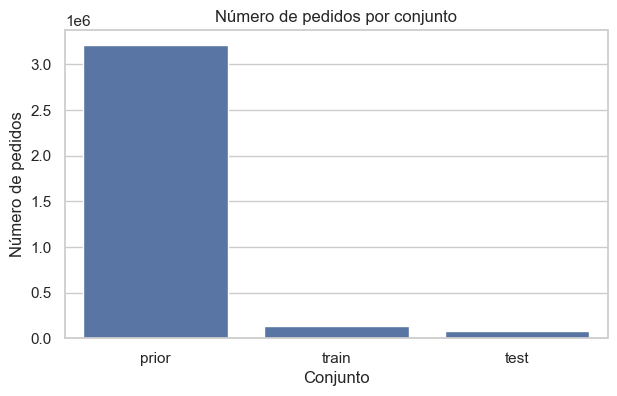

In [17]:
conteo_eval = orders["eval_set"].value_counts()

display(conteo_eval)

plt.figure(figsize=(7, 4))
sns.barplot(
    x=conteo_eval.index,
    y=conteo_eval.values
)

plt.title("Número de pedidos por conjunto")
plt.xlabel("Conjunto")
plt.ylabel("Número de pedidos")
plt.show()

In [18]:
pedidos_por_cliente = (
    orders.groupby("user_id")["order_id"]
    .nunique()
)

display(pedidos_por_cliente.describe())

count   206,209.00
mean         16.59
std          16.65
min           4.00
25%           6.00
50%          10.00
75%          20.00
max         100.00
Name: order_id, dtype: float64

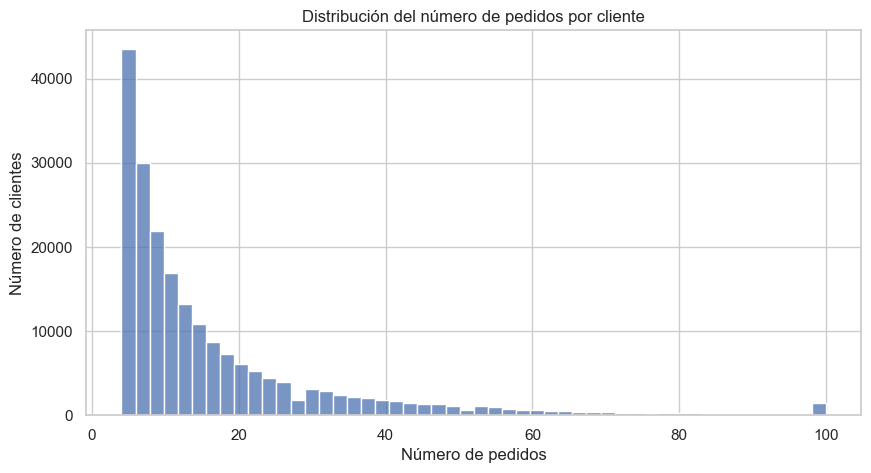

In [19]:
plt.figure(figsize=(10, 5))

sns.histplot(
    pedidos_por_cliente,
    bins=50
)

plt.title("Distribución del número de pedidos por cliente")
plt.xlabel("Número de pedidos")
plt.ylabel("Número de clientes")
plt.show()

#### Por día de la semana

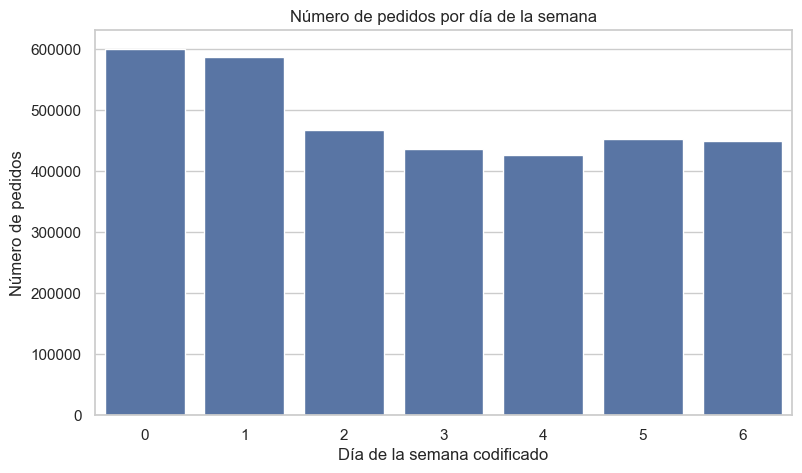

In [20]:
pedidos_por_dia = (
    orders["order_dow"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=pedidos_por_dia.index,
    y=pedidos_por_dia.values
)

plt.title("Número de pedidos por día de la semana")
plt.xlabel("Día de la semana codificado")
plt.ylabel("Número de pedidos")
plt.show()

#### Por hora

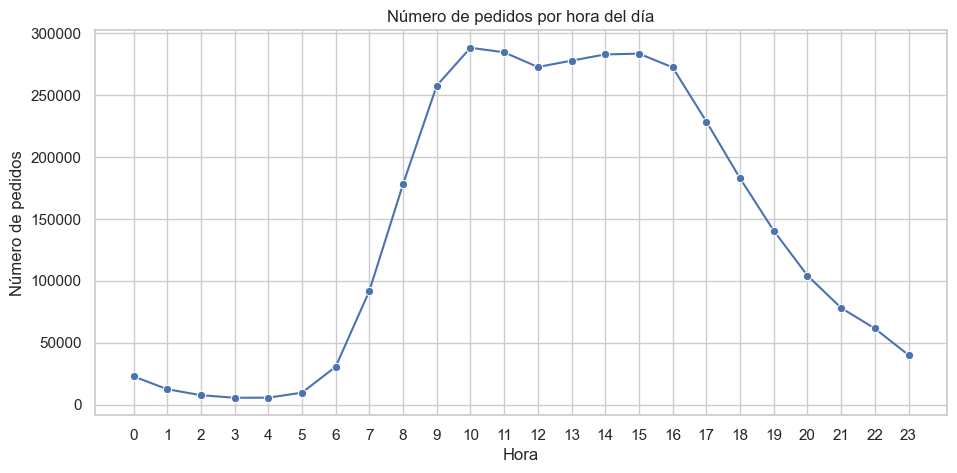

In [21]:
pedidos_por_hora = (
    orders["order_hour_of_day"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(11, 5))

sns.lineplot(
    x=pedidos_por_hora.index,
    y=pedidos_por_hora.values,
    marker="o"
)

plt.title("Número de pedidos por hora del día")
plt.xlabel("Hora")
plt.ylabel("Número de pedidos")
plt.xticks(range(24))
plt.show()

#### Por día y hora

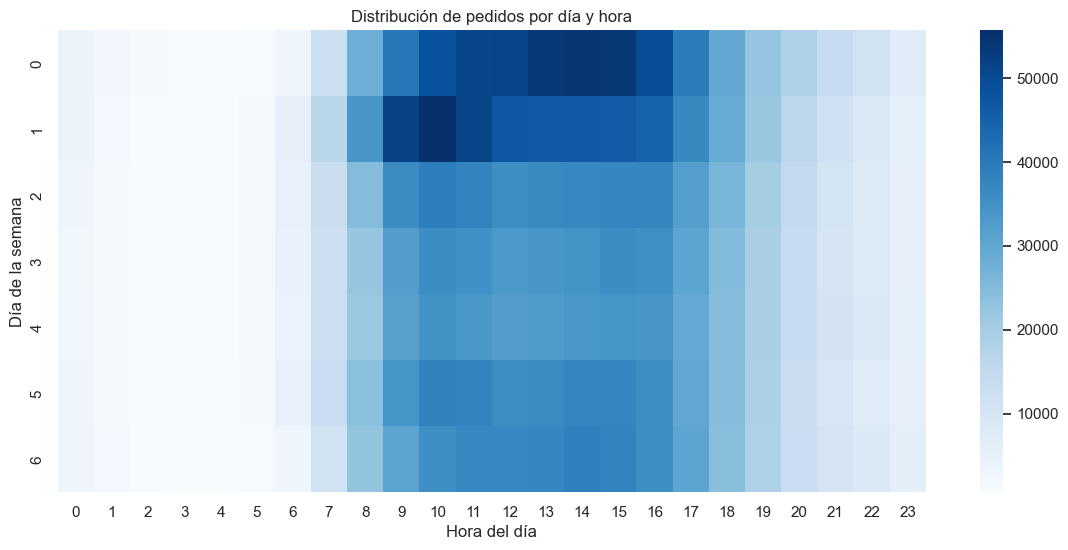

In [22]:
pedidos_dia_hora = pd.crosstab(
    orders["order_dow"],
    orders["order_hour_of_day"]
)

plt.figure(figsize=(14, 6))

sns.heatmap(
    pedidos_dia_hora,
    cmap="Blues"
)

plt.title("Distribución de pedidos por día y hora")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana")
plt.show()

#### Días desde el pedido anterior

In [23]:
display(
    orders["days_since_prior_order"].describe()
)

count   3,421,083.00
mean           10.44
std             9.31
min             0.00
25%             4.00
50%             7.00
75%            15.00
max            30.00
Name: days_since_prior_order, dtype: float64

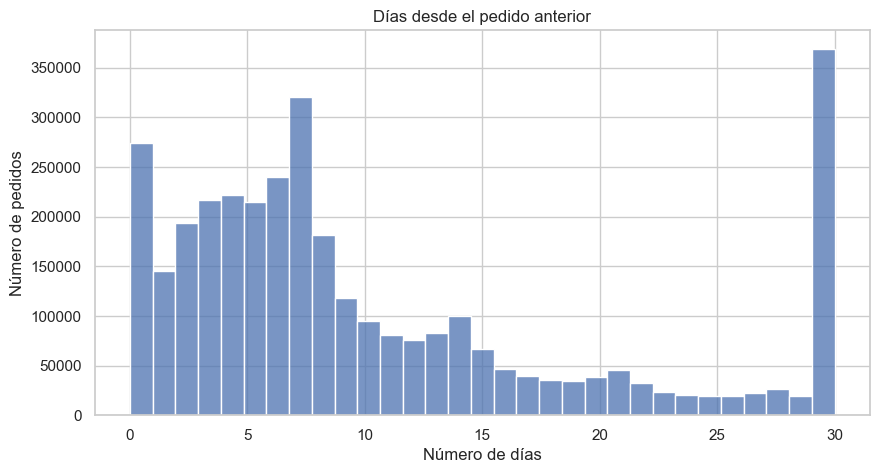

In [24]:
plt.figure(figsize=(10, 5))

sns.histplot(
    orders["days_since_prior_order"].dropna(),
    bins=31
)

plt.title("Días desde el pedido anterior")
plt.xlabel("Número de días")
plt.ylabel("Número de pedidos")
plt.show()

### Análisis de las cestas

#### Tamaño de las cestas

In [25]:
tamano_cestas = (
    order_products_prior
    .groupby("order_id")
    .size()
)

display(tamano_cestas.describe())

count   3,214,874.00
mean           10.09
std             7.53
min             1.00
25%             5.00
50%             8.00
75%            14.00
max           145.00
dtype: float64

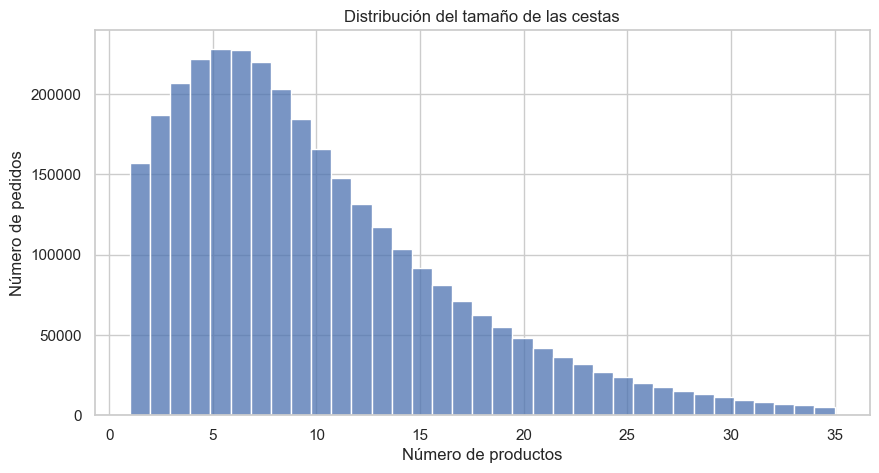

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(
    tamano_cestas[tamano_cestas <= tamano_cestas.quantile(0.99)],
    bins=35
)

plt.title("Distribución del tamaño de las cestas")
plt.xlabel("Número de productos")
plt.ylabel("Número de pedidos")
plt.show()

#### Recompra de productos

In [27]:
tasa_recompra = (
    order_products_prior["reordered"].mean()
)

print(f"Tasa general de recompra: {tasa_recompra:.2%}")

Tasa general de recompra: 58.97%


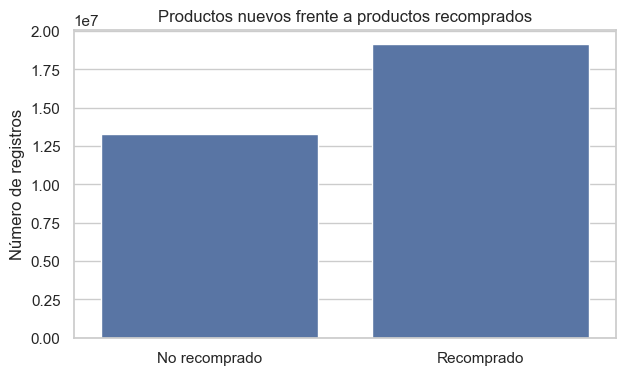

In [28]:
conteo_recompra = (
    order_products_prior["reordered"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 4))

sns.barplot(
    x=["No recomprado", "Recomprado"],
    y=conteo_recompra.values
)

plt.title("Productos nuevos frente a productos recomprados")
plt.ylabel("Número de registros")
plt.xlabel("")
plt.show()

#### Recompra según la posición en la cesta

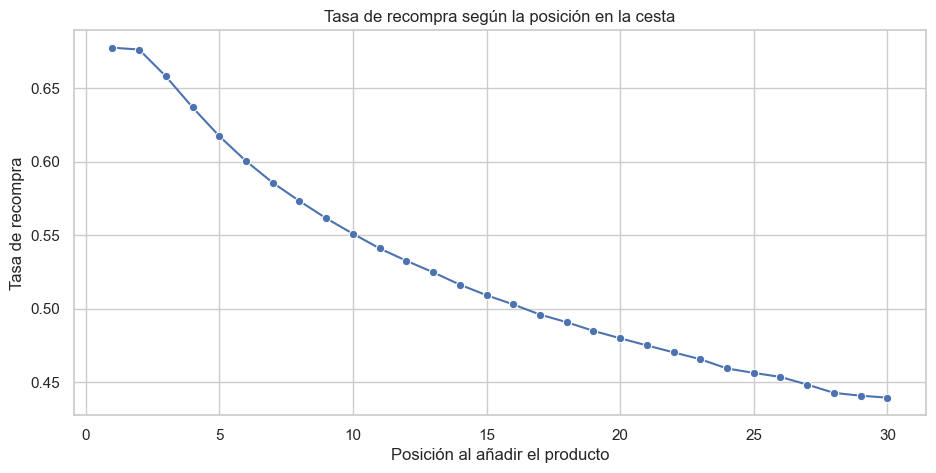

In [29]:
recompra_por_posicion = (
    order_products_prior
    .groupby("add_to_cart_order")["reordered"]
    .mean()
    .head(30)
)

plt.figure(figsize=(11, 5))

sns.lineplot(
    x=recompra_por_posicion.index,
    y=recompra_por_posicion.values,
    marker="o"
)

plt.title("Tasa de recompra según la posición en la cesta")
plt.xlabel("Posición al añadir el producto")
plt.ylabel("Tasa de recompra")
plt.show()

### Productos más comprados

In [30]:
products_complete = (
    products
    .merge(
        aisles,
        on="aisle_id",
        how="left"
    )
    .merge(
        departments,
        on="department_id",
        how="left"
    )
)

display(products_complete.head())

,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry


In [31]:
prior_complete = order_products_prior.merge(
    products_complete,
    on="product_id",
    how="left"
)

display(prior_complete.head())

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry


In [32]:
productos_mas_comprados = (
    prior_complete["product_name"]
    .value_counts()
    .head(20)
)

display(productos_mas_comprados)

product_name
Banana                      472565
Bag of Organic Bananas      379450
Organic Strawberries        264683
Organic Baby Spinach        241921
Organic Hass Avocado        213584
Organic Avocado             176815
Large Lemon                 152657
Strawberries                142951
Limes                       140627
Organic Whole Milk          137905
Organic Raspberries         137057
Organic Yellow Onion        113426
Organic Garlic              109778
Organic Zucchini            104823
Organic Blueberries         100060
Cucumber Kirby               97315
Organic Fuji Apple           89632
Organic Lemon                87746
Apple Honeycrisp Organic     85020
Organic Grape Tomatoes       84255
Name: count, dtype: int64

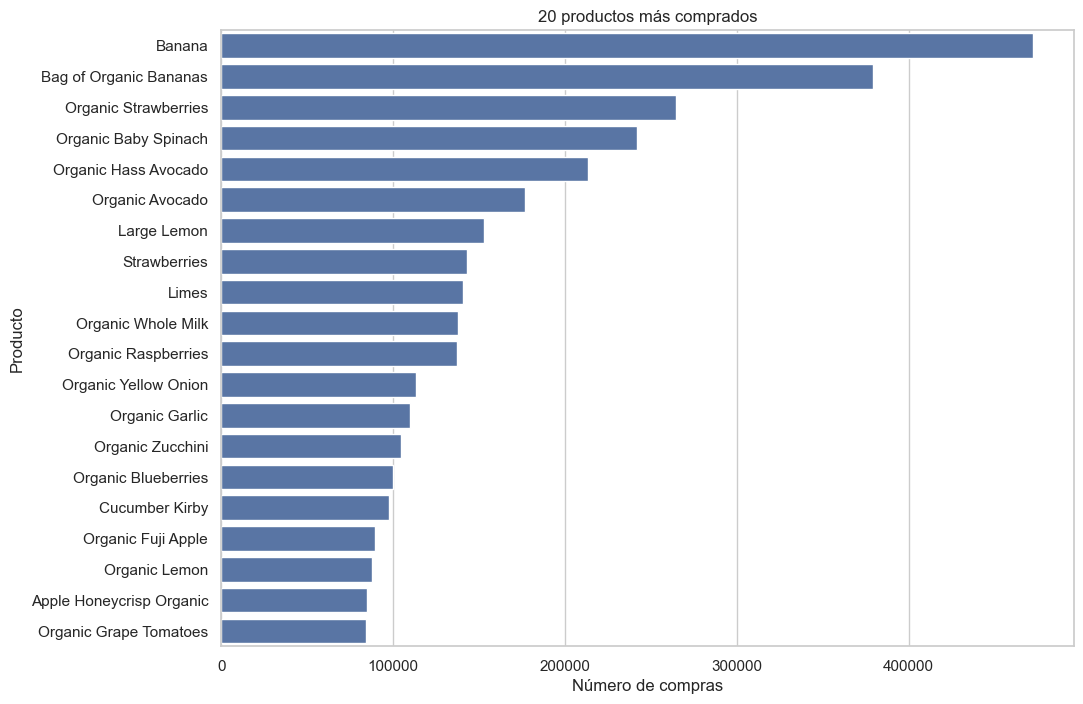

In [33]:
plt.figure(figsize=(11, 8))

sns.barplot(
    x=productos_mas_comprados.values,
    y=productos_mas_comprados.index
)

plt.title("20 productos más comprados")
plt.xlabel("Número de compras")
plt.ylabel("Producto")
plt.show()

### Productos con mayor tasa de recompra

In [34]:
estadisticas_producto = (
    prior_complete
    .groupby(
        ["product_id", "product_name"],
        as_index=False
    )
    .agg(
        numero_compras=("order_id", "count"),
        tasa_recompra=("reordered", "mean")
    )
)

estadisticas_producto.head()

,product_id,product_name,numero_compras,tasa_recompra
0,1,Chocolate Sandwich Cookies,1852,0.61
1,2,All-Seasons Salt,90,0.13
2,3,Robust Golden Unsweetened Oolong Tea,277,0.73
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,329,0.45
4,5,Green Chile Anytime Sauce,15,0.60


In [35]:
productos_recompra = (
    estadisticas_producto[
        estadisticas_producto["numero_compras"] >= 1_000
    ]
    .sort_values(
        "tasa_recompra",
        ascending=False
    )
    .head(20)
)

display(productos_recompra)

,product_id,product_name,numero_compras,tasa_recompra
9288,9292,Half And Half Ultra Pasteurized,2921,0.86
45495,45504,Whole Organic Omega 3 Milk,9108,0.86
43386,43394,Organic Lactose Free Whole Milk,8477,0.86
5511,5514,Organic Homogenized Whole Milk,3970,0.86
47220,47231,Ultra-Purified Water,1489,0.86
29441,29447,"Milk, Organic, Vitamin D",20198,0.85
38681,38689,Organic Reduced Fat Milk,35663,0.85
34191,34197,Goat Milk,5185,0.85
24848,24852,Banana,472565,0.84
31714,31720,Organic Whole Milk,9842,0.84


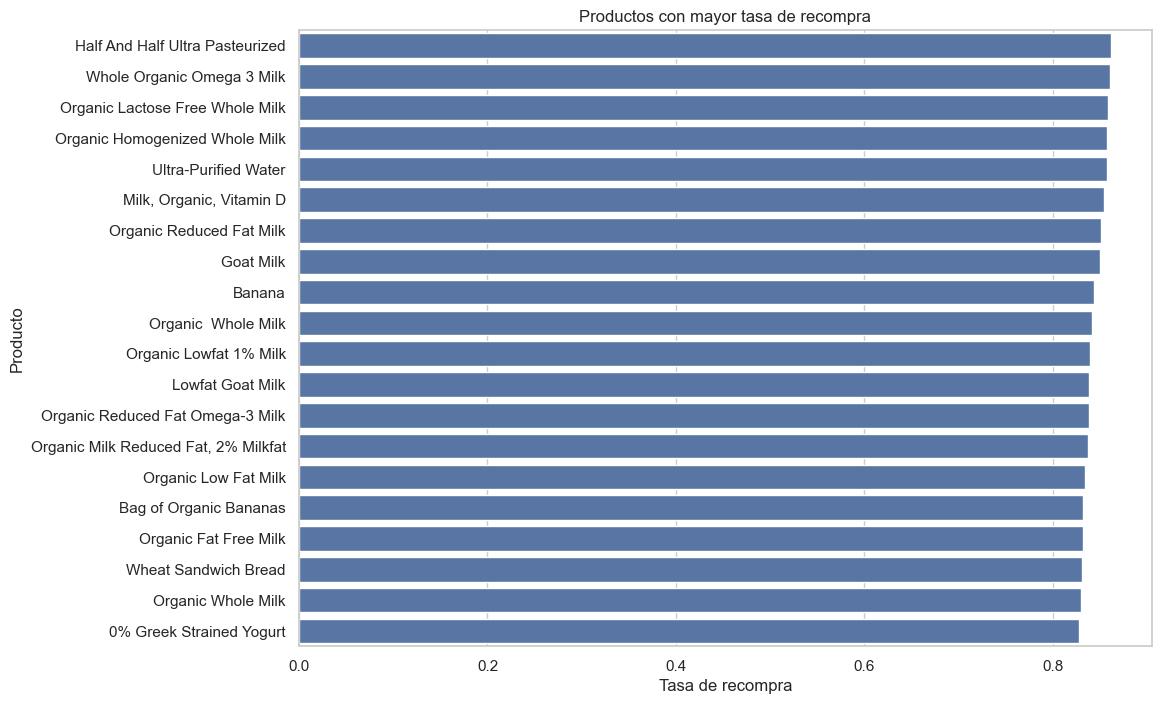

In [36]:
plt.figure(figsize=(11, 8))

sns.barplot(
    data=productos_recompra,
    x="tasa_recompra",
    y="product_name"
)

plt.title("Productos con mayor tasa de recompra")
plt.xlabel("Tasa de recompra")
plt.ylabel("Producto")
plt.show()

### Departamentos más comprados

In [37]:
compras_departamento = (
    prior_complete["department"]
    .value_counts()
)

display(compras_departamento)

department
produce            9479291
dairy eggs         5414016
snacks             2887550
beverages          2690129
frozen             2236432
pantry             1875577
bakery             1176787
canned goods       1068058
deli               1051249
dry goods pasta     866627
household           738666
breakfast           709569
meat seafood        708931
personal care       447123
babies              423802
international       269253
alcohol             153696
pets                 97724
missing              69145
other                36291
bulk                 34573
Name: count, dtype: int64

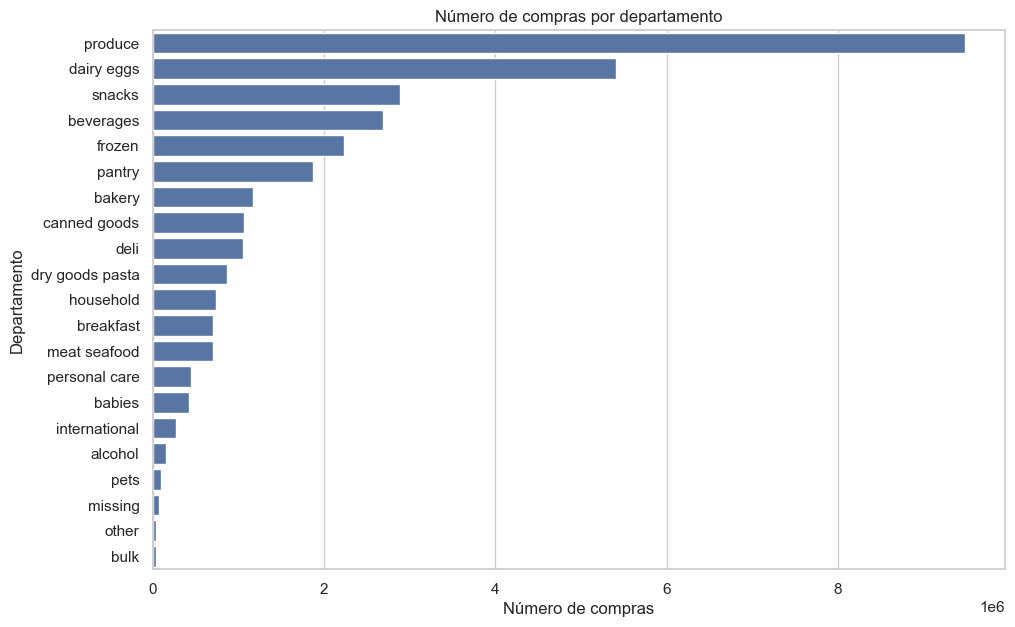

In [38]:
plt.figure(figsize=(11, 7))

sns.barplot(
    x=compras_departamento.values,
    y=compras_departamento.index
)

plt.title("Número de compras por departamento")
plt.xlabel("Número de compras")
plt.ylabel("Departamento")
plt.show()

### Tasa de recompra por departamento

In [39]:
recompra_departamento = (
    prior_complete
    .groupby("department", observed=True)["reordered"]
    .mean()
    .sort_values(ascending=False)
)

display(recompra_departamento)

department
dairy eggs        0.67
beverages         0.65
produce           0.65
bakery            0.63
deli              0.61
pets              0.60
babies            0.58
bulk              0.58
snacks            0.57
alcohol           0.57
meat seafood      0.57
breakfast         0.56
frozen            0.54
dry goods pasta   0.46
canned goods      0.46
other             0.41
household         0.40
missing           0.40
international     0.37
pantry            0.35
personal care     0.32
Name: reordered, dtype: float64

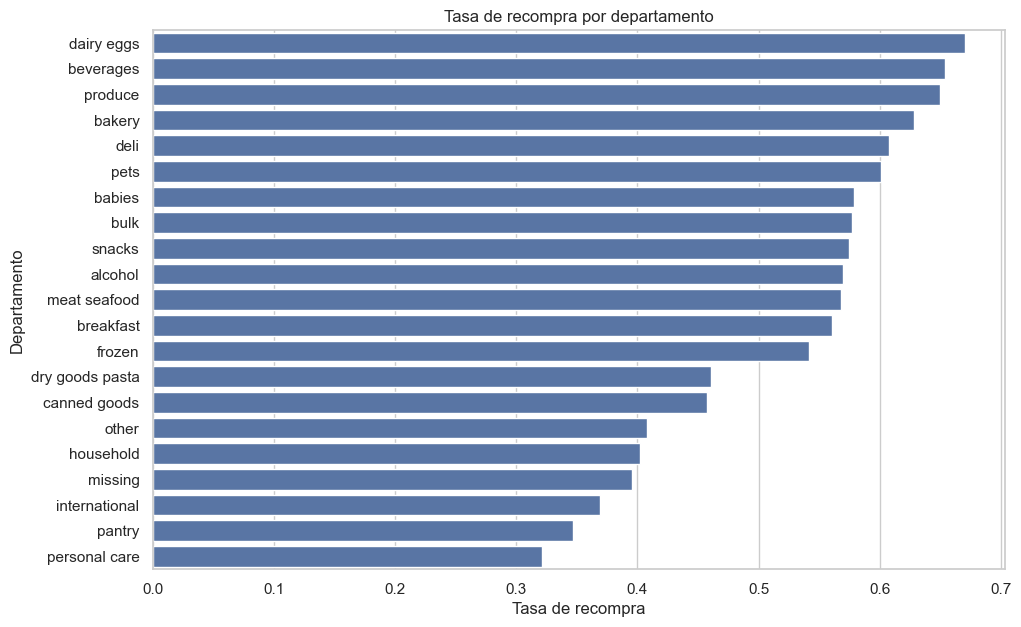

In [40]:
plt.figure(figsize=(11, 7))

sns.barplot(
    x=recompra_departamento.values,
    y=recompra_departamento.index
)

plt.title("Tasa de recompra por departamento")
plt.xlabel("Tasa de recompra")
plt.ylabel("Departamento")
plt.show()

### Pasillos más utilizados

In [41]:
pasillos_mas_comprados = (
    prior_complete["aisle"]
    .value_counts()
    .head(20)
)

display(pasillos_mas_comprados)

aisle
fresh fruits                     3642188
fresh vegetables                 3418021
packaged vegetables fruits       1765313
yogurt                           1452343
packaged cheese                   979763
milk                              891015
water seltzer sparkling water     841533
chips pretzels                    722470
soy lactosefree                   638253
bread                             584834
refrigerated                      575881
frozen produce                    522654
ice cream ice                     498425
crackers                          458838
energy granola bars               456386
eggs                              452134
lunch meat                        395130
frozen meals                      390299
baby food formula                 382456
fresh herbs                       377741
Name: count, dtype: int64

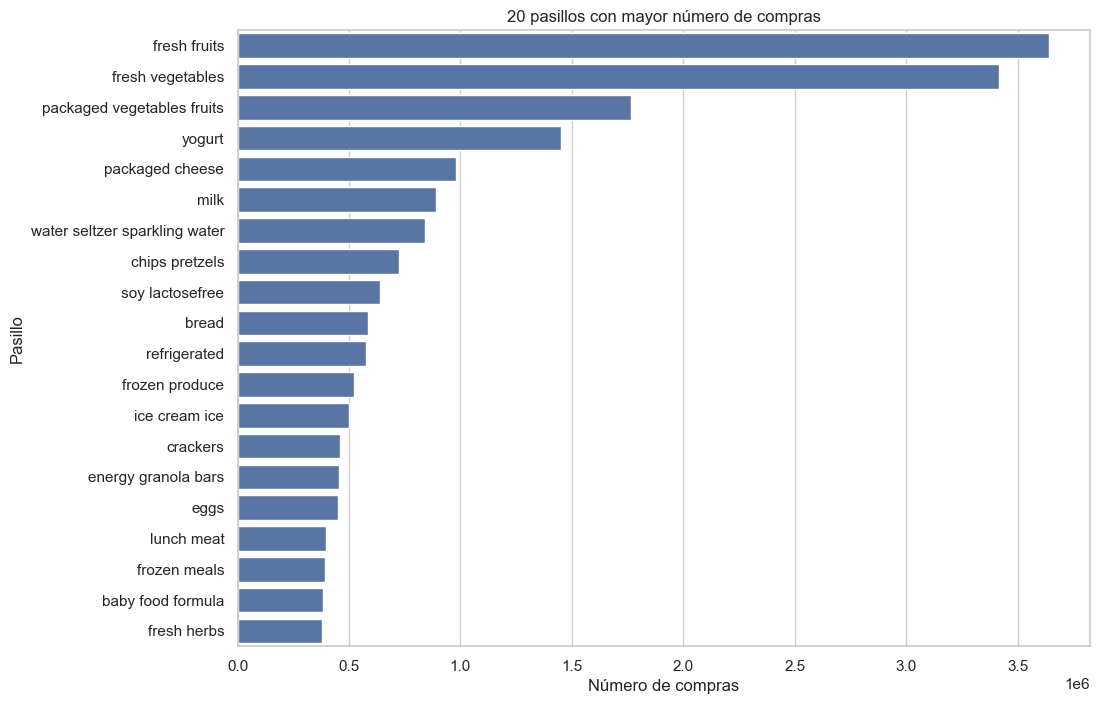

In [42]:
plt.figure(figsize=(11, 8))

sns.barplot(
    x=pasillos_mas_comprados.values,
    y=pasillos_mas_comprados.index
)

plt.title("20 pasillos con mayor número de compras")
plt.xlabel("Número de compras")
plt.ylabel("Pasillo")
plt.show()

### Tamaño de cesta según día y hora

In [43]:
cestas = (
    order_products_prior
    .groupby("order_id")
    .size()
    .reset_index(name="tamano_cesta")
)

cestas = cestas.merge(
    orders[
        [
            "order_id",
            "order_dow",
            "order_hour_of_day"
        ]
    ],
    on="order_id",
    how="left"
)

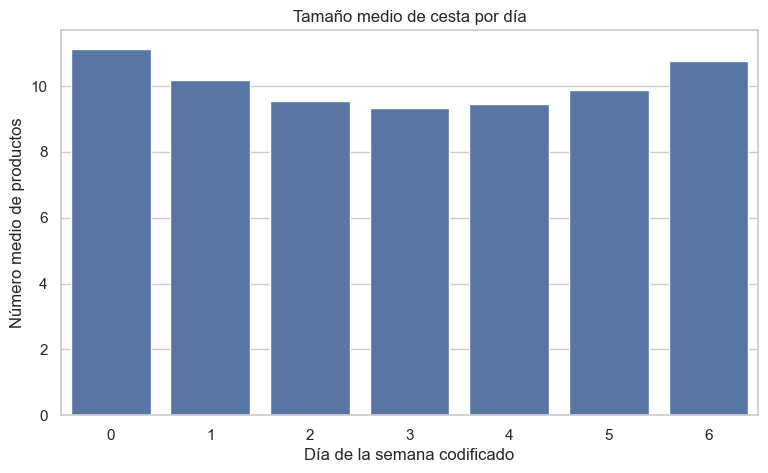

In [44]:
tamano_medio_dia = (
    cestas
    .groupby("order_dow")["tamano_cesta"]
    .mean()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=tamano_medio_dia.index,
    y=tamano_medio_dia.values
)

plt.title("Tamaño medio de cesta por día")
plt.xlabel("Día de la semana codificado")
plt.ylabel("Número medio de productos")
plt.show()

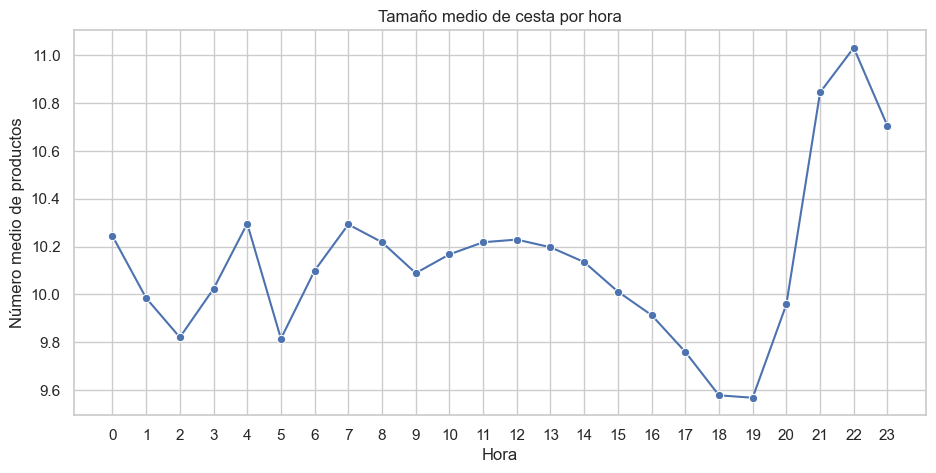

In [45]:
tamano_medio_hora = (
    cestas
    .groupby("order_hour_of_day")["tamano_cesta"]
    .mean()
)

plt.figure(figsize=(11, 5))

sns.lineplot(
    x=tamano_medio_hora.index,
    y=tamano_medio_hora.values,
    marker="o"
)

plt.title("Tamaño medio de cesta por hora")
plt.xlabel("Hora")
plt.ylabel("Número medio de productos")
plt.xticks(range(24))
plt.show()